In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Notebook path: src/notebooks/test.ipynb -> parquet in src/data/bronze
parquet_path = (Path.cwd().parent / "data" / "bronze" / "sqr_daily_by_station.parquet").resolve()
print(f"Parquet path: {parquet_path}")

if not parquet_path.exists():
    raise FileNotFoundError(
        f"Fichier introuvable: {parquet_path}\n"
        "Vérifie que le script raw_to_bronze_rte.py a bien été exécuté."
    )

df = pd.read_parquet(parquet_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

print(f"Shape: {df.shape}")
display(df.head())

Parquet path: /home/camille/code/Camille9999/EPSI/M2/EPSI-M2_MSPR/src/data/bronze/sqr_daily_by_station.parquet
Shape: (27029, 378)


,date,TN_002037002,TN_003180001,TN_020247001,TN_028322001,TN_081081002,TN_091184001,TN_102705001,TN_110323001,TN_117243002,...,TX_386027001,TX_394068001,TX_395088001,TX_418033001,TX_450020001,TX_459183001,TX_459343001,TX_460639001,TX_462160001,TX_475114001
0,1951-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.2,NaN,NaN,NaN,NaN,NaN,3.4,NaN,4.8,NaN
1,1951-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.4,NaN,NaN,NaN,NaN,NaN,3.5,NaN,4.2,NaN
2,1951-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,2.6,NaN,4.6,NaN
3,1951-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.9,NaN,NaN,NaN,NaN,NaN,6.8,NaN,7.8,NaN
4,1951-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.2,NaN,NaN,NaN,NaN,NaN,9.1,NaN,9.6,NaN


Nombre de colonnes TN: 179
Nombre de colonnes TX: 198


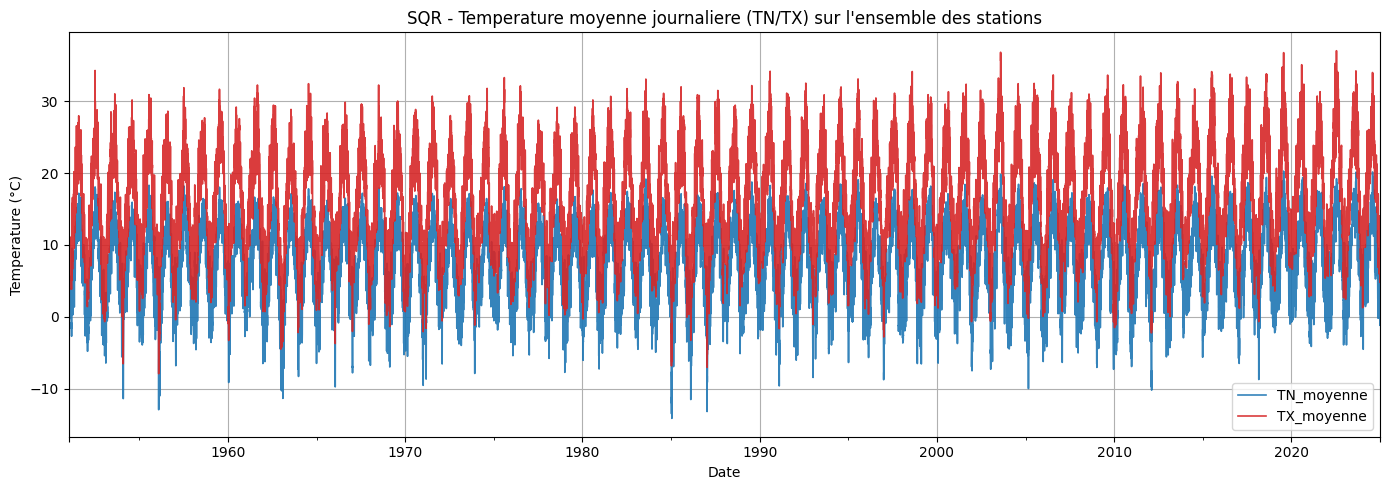

In [2]:
tn_cols = [c for c in df.columns if c.startswith("TN_")]
tx_cols = [c for c in df.columns if c.startswith("TX_")]

print(f"Nombre de colonnes TN: {len(tn_cols)}")
print(f"Nombre de colonnes TX: {len(tx_cols)}")

# Serie moyenne journaliere sur toutes les stations disponibles
plot_df = pd.DataFrame({
    "date": df["date"],
    "TN_moyenne": df[tn_cols].mean(axis=1, skipna=True),
    "TX_moyenne": df[tx_cols].mean(axis=1, skipna=True),
}).dropna(subset=["date"])

ax = plot_df.plot(
    x="date",
    y=["TN_moyenne", "TX_moyenne"],
    figsize=(14, 5),
    title="SQR - Temperature moyenne journaliere (TN/TX) sur l'ensemble des stations",
    linewidth=1.2,
    alpha=0.9,
    grid=True,
    color=["#1f77b4", "#d62728"],
)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

In [4]:
def dates_to_ranges(dates):
    """Transforme une liste de dates en plages continues [start, end]."""
    if len(dates) == 0:
        return []

    dates = pd.DatetimeIndex(sorted(pd.to_datetime(dates).unique()))
    ranges = []
    start = dates[0]
    prev = dates[0]

    for current in dates[1:]:
        if (current - prev).days == 1:
            prev = current
            continue
        ranges.append((start, prev))
        start = current
        prev = current

    ranges.append((start, prev))
    return ranges


analysis_df = df.copy()
analysis_df = analysis_df.sort_values("date").reset_index(drop=True)
analysis_df = analysis_df.set_index("date")

station_cols = [c for c in analysis_df.columns if c.startswith("TN_") or c.startswith("TX_")]

# 1) Taux de valeurs manquantes par colonne
missing_rate = analysis_df[station_cols].isna().mean().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "colonne": missing_rate.index,
    "taux_manquant": missing_rate.values,
    "nb_manquant": analysis_df[station_cols].isna().sum().reindex(missing_rate.index).values,
})

print("Top 15 colonnes avec le plus de valeurs manquantes:")
display(missing_summary.head(15))

# 2) Plages où TOUTES les stations ont une valeur (TN et TX)
complete_mask = analysis_df[station_cols].notna().all(axis=1)
complete_dates = analysis_df.index[complete_mask]
complete_ranges = dates_to_ranges(complete_dates)

complete_ranges_df = pd.DataFrame(
    [
        {
            "debut": start,
            "fin": end,
            "nb_jours": (end - start).days + 1,
        }
        for start, end in complete_ranges
    ]
)

print("Plages temporelles avec couverture complète (toutes les stations renseignées):")
if complete_ranges_df.empty:
    print("Aucune date ne contient des valeurs pour l'ensemble des stations.")
else:
    display(
        complete_ranges_df
        .sort_values(["debut"])
        .reset_index(drop=True)
    )

    longest_range = complete_ranges_df.sort_values("nb_jours", ascending=False).iloc[0]
    print(
        "Plage continue la plus longue avec couverture complète : "
        f"{longest_range['debut'].date()} -> {longest_range['fin'].date()} "
        f"({int(longest_range['nb_jours'])} jours)"
    )

    global_start = complete_dates.min().date()
    global_end = complete_dates.max().date()
    print(
        "Fenêtre globale contenant au moins une date complètement couverte : "
        f"{global_start} -> {global_end}"
    )

# 3) Plages de valeurs manquantes par station (NaN dans les colonnes)
rows = []
for col in station_cols:
    missing_dates_col = analysis_df.index[analysis_df[col].isna()]
    if len(missing_dates_col) == 0:
        continue
    ranges = dates_to_ranges(missing_dates_col)
    for start, end in ranges:
        rows.append(
            {
                "colonne": col,
                "debut": start,
                "fin": end,
                "nb_jours": (end - start).days + 1,
            }
        )

missing_ranges_by_station = pd.DataFrame(rows)

print("Plages de valeurs manquantes par station (aperçu des 30 plus longues):")
if missing_ranges_by_station.empty:
    print("Aucune valeur manquante dans les colonnes station.")
else:
    display(
        missing_ranges_by_station
        .sort_values(["nb_jours", "colonne"], ascending=[False, True])
        .head(30)
        .reset_index(drop=True)
    )

Top 15 colonnes avec le plus de valeurs manquantes:


,colonne,taux_manquant,nb_manquant
0,TN_091184001,0.551371,14903
1,TX_091184001,0.551371,14903
2,TX_273306005,0.548337,14821
3,TX_269264001,0.543490,14690
4,TX_209023002,0.542010,14650
5,TX_219034001,0.541418,14634
6,TN_185163001,0.541344,14632
7,TX_127112001,0.540975,14622
8,TX_177333003,0.540716,14615
9,TN_177333003,0.540679,14614


Plages temporelles avec couverture complète (toutes les stations renseignées):


,debut,fin,nb_jours
0,1991-09-01,1991-10-20,50
1,1992-03-01,1992-03-20,20
2,1992-03-22,1992-04-30,40
3,1992-11-01,1992-11-30,30
4,1993-01-01,1993-04-08,98
...,...,...,...
88,2020-07-01,2020-07-23,23
89,2020-10-17,2021-07-12,269
90,2021-07-14,2021-12-13,153
91,2021-12-15,2022-02-12,60


Plage continue la plus longue avec couverture complète : 2008-05-01 -> 2010-01-24 (634 jours)
Fenêtre globale contenant au moins une date complètement couverte : 1991-09-01 -> 2022-05-01
Plages de valeurs manquantes par station (aperçu des 30 plus longues):


,colonne,debut,fin,nb_jours
0,TX_273306005,1951-01-01,1991-06-30,14791
1,TN_091184001,1951-01-01,1990-12-31,14610
2,TN_122372001,1951-01-01,1990-12-31,14610
3,TN_128363001,1951-01-01,1990-12-31,14610
4,TN_177333003,1951-01-01,1990-12-31,14610
5,TN_185163001,1951-01-01,1990-12-31,14610
6,TN_214578001,1951-01-01,1990-12-31,14610
7,TN_226330001,1951-01-01,1990-12-31,14610
8,TN_243096001,1951-01-01,1990-12-31,14610
9,TN_352269001,1951-01-01,1990-12-31,14610
